# Pandas ile Veri Analizi (Titanic Veri seti)

Veriye [bu linkten](https://github.com/pandas-dev/pandas/blob/main/doc/data/titanic.csv) ulaşabilirsiniz.


## Import Library

In [2]:
import pandas as pd

## Veriyi Yükleme


In [3]:
# Url'den veri Yükleme
url='https://raw.githubusercontent.com/pandas-dev/pandas/refs/heads/main/doc/data/titanic.csv'
df = pd.read_csv(url)

In [4]:
df.sample(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
130,131,0,3,"Drazenoic, Mr. Jozef",male,33.0,0,0,349241,7.8958,NaN,C
575,576,0,3,"Patchett, Mr. George",male,19.0,0,0,358585,14.5000,NaN,S
243,244,0,3,"Maenpaa, Mr. Matti Alexanteri",male,22.0,0,0,STON/O 2. 3101275,7.1250,NaN,S
684,685,0,2,"Brown, Mr. Thomas William Solomon",male,60.0,1,1,29750,39.0000,NaN,S
486,487,1,1,"Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)",female,35.0,1,0,19943,90.0000,C93,S
539,540,1,1,"Frolicher, Miss Hedwig Margaritha",female,22.0,0,2,13568,49.5000,B39,C
335,336,0,3,"Denkoff, Mr. Mitto",male,NaN,0,0,349225,7.8958,NaN,S


## Veri sayısı: `value_counts()`


In [5]:
df.Sex.value_counts()

,count
Sex,
male,577
female,314


In [6]:
df.Age.value_counts()

,count
Age,
24.00,30
22.00,27
18.00,26
28.00,25
30.00,25
...,...
24.50,1
0.67,1
0.42,1


### Normalize (oran)

In [8]:
df.Age.value_counts(normalize=True)

,proportion
Age,
24.00,0.042017
22.00,0.037815
18.00,0.036415
28.00,0.035014
30.00,0.035014
...,...
24.50,0.001401
0.67,0.001401
0.42,0.001401


## `Groupby` Fonksiyonu

Sütunlar arasında gruplandırmalar yaparak detaylı inceleme yapabilmemizi sağlar.


### Cinsiyete göre hayatta kalma

In [9]:
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


### Sınıfa göre ortalama ücret

In [10]:
df.groupby("Pclass")["Fare"].mean()

,Fare
Pclass,
1,84.154687
2,20.662183
3,13.675550


In [11]:
df.groupby("Pclass")["Fare"].max()

,Fare
Pclass,
1,512.3292
2,73.5000
3,69.5500


### Çoklu grup

In [12]:
df.groupby(["Sex","Pclass"])["Survived"].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

## `Groupby + Agg` Fonksiyonu


### Aggfuntion

`aggfunc="min"`

`aggfunc="mean"`

`aggfunc="max"`

`aggfunc="std"`

`aggfunc="sum"`

`aggfunc="count"`



In [13]:
df.groupby("Pclass").agg({"Age":"mean","Fare":["mean","max"],"Survived":"mean"})

Age       Fare            Survived
             mean       mean       max      mean
Pclass                                          
1       38.233441  84.154687  512.3292  0.629630
2       29.877630  20.662183   73.5000  0.472826
3       25.140620  13.675550   69.5500  0.242363

## Transform

In [14]:
df["class_avg_fare"] = df.groupby('Pclass')['Fare'].transform('mean')

In [15]:
df.sample(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,class_avg_fare
692,693,1,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S,13.675550
10,11,1,3,"Sandstrom, Miss Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,13.675550
39,40,1,3,"Nicola-Yarred, Miss Jamila",female,14.0,1,0,2651,11.2417,NaN,C,13.675550
694,695,0,1,"Weir, Col. John",male,60.0,0,0,113800,26.5500,NaN,S,84.154687
476,477,0,2,"Renouf, Mr. Peter Henry",male,34.0,1,0,31027,21.0000,NaN,S,20.662183
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.5500,NaN,S,13.675550
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S,84.154687


### Sapma

In [16]:
df["fare_diff"] = df.Fare - df.class_avg_fare

In [17]:
df["fare_diff"].sample(7)

,fare_diff
577,-28.254687
436,20.699450
458,-10.162183
72,52.837817
571,-32.675487
810,-5.788050
493,-34.650487


## `Apply()` Fonksiyonu

In [18]:
def kategori(yas):

 if yas<18:
   return "Çocuk"

 elif yas<60:
   return "Yetişkin"

 else:
   return "Yaşlı"


df["yas_grubu"]= df.Age.apply(kategori)

In [19]:
df.sample(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,class_avg_fare,fare_diff,yas_grubu
529,530,0,2,"Hocking, Mr. Richard George",male,23.0,2,1,29104,11.500,NaN,S,20.662183,-9.162183,Yetişkin
247,248,1,2,"Hamalainen, Mrs. William (Anna)",female,24.0,0,2,250649,14.500,NaN,S,20.662183,-6.162183,Yetişkin
693,694,0,3,"Saad, Mr. Khalil",male,25.0,0,0,2672,7.225,NaN,C,13.675550,-6.450550,Yetişkin
137,138,0,1,"Futrelle, Mr. Jacques Heath",male,37.0,1,0,113803,53.100,C123,S,84.154687,-31.054687,Yetişkin
654,655,0,3,"Hegarty, Miss Hanora ""Nora""",female,18.0,0,0,365226,6.750,NaN,Q,13.675550,-6.925550,Yetişkin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.250,NaN,S,13.675550,-6.425550,Yetişkin


## `Crosstab` Fonksiyonu

iki veya daha fazla kategorik değişken arasındaki ilişkiyi incelemek için kullanılan bir çapraz tablo oluşturur.

In [20]:
pd.crosstab(df.Sex, df.Survived)

Survived,0,1
Sex,,
female,81,233
male,468,109


### Normalize

In [21]:
pd.crosstab(df.Sex, df.Survived, normalize='index')

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


### Toplam Görüntüleme

In [22]:
pd.crosstab(df.Sex, df.Survived, margins=True)

Survived,0,1,All
Sex,,,
female,81,233,314
male,468,109,577
All,549,342,891


### Çoklu Kategorilerle Kullanım

In [23]:
pd.crosstab([df.Sex, df.Survived], df.Pclass)

Pclass            1   2    3
Sex    Survived             
female 0          3   6   72
       1         91  70   72
male   0         77  91  300
       1         45  17   47

### Ortalama Hesaplama

In [24]:
pd.crosstab(
    df["Pclass"],
    df["Sex"],
    values=df["Age"],
    aggfunc="mean"
)

Sex,female,male
Pclass,,
1,34.611765,41.281386
2,28.722973,30.740707
3,21.750000,26.507589


## Pivot Table

verileri belirli kategorilere göre özetlemek, gruplamak ve istatistiksel analiz yapmak için kullanılır.

In [25]:
pd.pivot_table(df, values='Survived', index='Sex', columns='Pclass', aggfunc="count")

Pclass,1,2,3
Sex,,,
female,94,76,144
male,122,108,347


In [26]:
pd.pivot_table(
    df,
    values='Age',
    index='Sex',
    aggfunc=["min", "mean", "max", "std", "count"]
)

,min,mean,max,std,count
,Age,Age,Age,Age,Age
Sex,,,,,
female,0.75,27.915709,63.0,14.110146,261
male,0.42,30.726645,80.0,14.678201,453


In [27]:
pd.pivot_table(
    df,
    values="Survived",
    index=["Pclass", "Sex"],
    columns="Embarked",
    aggfunc="count"
)

Embarked        C   Q    S
Pclass Sex                
1      female  43   1   48
       male    42   1   79
2      female   7   2   67
       male    10   1   97
3      female  23  33   88
       male    43  39  265

## MultiIndex Kavramı

In [28]:
summary_df = pd.pivot_table(
    df,
    values="Survived",
    index=["Pclass", "Sex"],
    columns="Embarked",
    aggfunc="count"
)

summary_df

Embarked        C   Q    S
Pclass Sex                
1      female  43   1   48
       male    42   1   79
2      female   7   2   67
       male    10   1   97
3      female  23  33   88
       male    43  39  265

In [29]:
summary_df.reset_index()

Embarked,Pclass,Sex,C,Q,S
0,1,female,43,1,48
1,1,male,42,1,79
2,2,female,7,2,67
3,2,male,10,1,97
4,3,female,23,33,88
5,3,male,43,39,265


## Duplicate

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.drop_duplicates()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,class_avg_fare,fare_diff,yas_grubu
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,13.675550,-6.425550,Yetişkin
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,84.154687,-12.871387,Yetişkin
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,13.675550,-5.750550,Yetişkin
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,84.154687,-31.054687,Yetişkin
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,13.675550,-5.625550,Yetişkin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,20.662183,-7.662183,Yetişkin
887,888,1,1,"Graham, Miss Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,84.154687,-54.154687,Yetişkin
888,889,0,3,"Johnston, Miss Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,13.675550,9.774450,Yaşlı
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,84.154687,-54.154687,Yetişkin


## Merge

Ortak bir sütuna göre eşleştirme yaparak dataframeleri birleştirir.

`merge(df1, df2, on="specific_column",  how="left")`

* how="left"

* how="right"

* how="inner"

* how="outer"

In [34]:
extra=pd.DataFrame(
{
"Pclass":[1,2,3],
"Luxury":[1,0,0]
}
)

In [35]:
pd.merge(
df,
extra,
on='Pclass'
)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,class_avg_fare,fare_diff,yas_grubu,Luxury
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,13.675550,-6.425550,Yetişkin,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,84.154687,-12.871387,Yetişkin,1
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,13.675550,-5.750550,Yetişkin,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,84.154687,-31.054687,Yetişkin,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,13.675550,-5.625550,Yetişkin,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,20.662183,-7.662183,Yetişkin,0
887,888,1,1,"Graham, Miss Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,84.154687,-54.154687,Yetişkin,1
888,889,0,3,"Johnston, Miss Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,13.675550,9.774450,Yaşlı,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,84.154687,-54.154687,Yetişkin,1


### Basit Örnek

In [37]:
df1 = pd.DataFrame({
    "x1": ["A", "B", "C"],
    "x2": [1, 2, 3]
})

print(df1)

  x1  x2
0  A   1
1  B   2
2  C   3


In [38]:
df2 = pd.DataFrame({
    "x1": ["A", "B", "D"],
    "x3": ["T", "F", "T"]
})

print(df2)

  x1 x3
0  A  T
1  B  F
2  D  T


In [39]:
# left → Sol tabloyu koru
left_join = pd.merge(df1, df2,
                     how="left",
                     on="x1")

print("\n===== LEFT JOIN =====")
print(left_join)



===== LEFT JOIN =====
  x1  x2   x3
0  A   1    T
1  B   2    F
2  C   3  NaN


In [42]:
# right → Sağ tabloyu koru
right_join = pd.merge(df1, df2,
                      how="right",
                      on="x1")

print("\n===== RIGHT JOIN =====")
print(right_join)


===== RIGHT JOIN =====
  x1   x2 x3
0  A  1.0  T
1  B  2.0  F
2  D  NaN  T


In [43]:
# inner → Kesişim (ortak olanlar)
inner_join = pd.merge(df1, df2,
                      how="inner",
                      on="x1")

print("\n===== INNER JOIN =====")
print(inner_join)


===== INNER JOIN =====
  x1  x2 x3
0  A   1  T
1  B   2  F


In [44]:
# outer → Birleşim (hepsi)
outer_join = pd.merge(df1, df2,
                      how="outer",
                      on="x1")

print("\n===== OUTER JOIN =====")
print(outer_join)


===== OUTER JOIN =====
  x1   x2   x3
0  A  1.0    T
1  B  2.0    F
2  C  3.0  NaN
3  D  NaN    T


## Concat

`pd.concat()` birden fazla DataFrame’i:

* alt alta (axis=0)
* yan yana (axis=1)

birleştirmek için kullanılır.

### Satır

In [53]:
concat_rows = pd.concat([df1, df2])

print("\n===== SATIR BAZINDA CONCAT =====")
print(concat_rows)


===== SATIR BAZINDA CONCAT =====
  x1   x2   x3
0  A  1.0  NaN
1  B  2.0  NaN
2  C  3.0  NaN
0  A  NaN    T
1  B  NaN    F
2  D  NaN    T


In [57]:
concat_outer = pd.concat(
    [df1, df2],
    join="outer"
)

print("\n===== OUTER CONCAT =====")
print(concat_outer)


===== OUTER CONCAT =====
  x1   x2   x3
0  A  1.0  NaN
1  B  2.0  NaN
2  C  3.0  NaN
0  A  NaN    T
1  B  NaN    F
2  D  NaN    T


In [56]:
concat_inner = pd.concat(
    [df1, df2],
    join="inner"
)

print("\n===== INNER CONCAT =====")
print(concat_inner)


===== INNER CONCAT =====
  x1
0  A
1  B
2  C
0  A
1  B
2  D


### Sütun

In [58]:
concat_cols = pd.concat([df1, df2], axis=1)

print("\n===== SÜTUN BAZINDA CONCAT =====")
print(concat_cols)


===== SÜTUN BAZINDA CONCAT =====
  x1  x2 x1 x3
0  A   1  A  T
1  B   2  B  F
2  C   3  D  T


## `Melt` Fonksiyonu

* Geniş (wide) formatlı veriyi, uzun (long) formata dönüştürür.
* Sayısal sütunları tek sütun altında toplar.

In [61]:
sample_df = df[[
    "PassengerId",
    "Age",
    "Fare",
    "Survived"
]].head(5)

print("===== ORİJİNAL DATAFRAME =====")
print(sample_df)


===== ORİJİNAL DATAFRAME =====
   PassengerId   Age     Fare  Survived
0            1  22.0   7.2500         0
1            2  38.0  71.2833         1
2            3  26.0   7.9250         1
3            4  35.0  53.1000         1
4            5  35.0   8.0500         0


In [62]:
melted_df = pd.melt(
    sample_df,
    id_vars="PassengerId",      # Sabit kalacak sütun
    value_vars=["Age", "Fare", "Survived"],  # Eritilecek sütunlar
)

print("\n===== MELT SONUCU =====")
print(melted_df)


===== MELT SONUCU =====
    PassengerId  variable    value
0             1       Age  22.0000
1             2       Age  38.0000
2             3       Age  26.0000
3             4       Age  35.0000
4             5       Age  35.0000
5             1      Fare   7.2500
6             2      Fare  71.2833
7             3      Fare   7.9250
8             4      Fare  53.1000
9             5      Fare   8.0500
10            1  Survived   0.0000
11            2  Survived   1.0000
12            3  Survived   1.0000
13            4  Survived   1.0000
14            5  Survived   0.0000


In [63]:
melted_custom = pd.melt(
    sample_df,
    id_vars="PassengerId",
    value_vars=["Age", "Fare", "Survived"],
    var_name="Feature",
    value_name="Value"
)

print("\n===== ÖZEL SÜTUN İSİMLERİ =====")
print(melted_custom)


===== ÖZEL SÜTUN İSİMLERİ =====
    PassengerId   Feature    Value
0             1       Age  22.0000
1             2       Age  38.0000
2             3       Age  26.0000
3             4       Age  35.0000
4             5       Age  35.0000
5             1      Fare   7.2500
6             2      Fare  71.2833
7             3      Fare   7.9250
8             4      Fare  53.1000
9             5      Fare   8.0500
10            1  Survived   0.0000
11            2  Survived   1.0000
12            3  Survived   1.0000
13            4  Survived   1.0000
14            5  Survived   0.0000


## `Map` ve `Replace` Fonksiyonları

* Map: Bir sütundaki değerleri başka değerlerle eşleştirir.

* Replace: DataFrame veya sütun içindeki değerleri değiştirir.

Replace map'ten farklı olarak:
- tüm DataFrame üzerinde çalışabilir.
- çoklu değiştirme yapabilir.

In [67]:
df["Sex_Encoded"] = df["Sex"].map({"male": 0,"female": 1})

print("===== MAP =====")
print(df[["Sex", "Sex_Encoded"]].head())

===== MAP =====
      Sex  Sex_Encoded
0    male            0
1  female            1
2  female            1
3  female            1
4    male            0


In [68]:
sex_replaced = df["Sex"].replace({
    "male": "Erkek",
    "female": "Kadın"
})

print("\n===== REPLACE =====")
print(sex_replaced.head())


===== REPLACE =====
0    Erkek
1    Kadın
2    Kadın
3    Kadın
4    Erkek
Name: Sex, dtype: object


In [69]:
small_df = df[["Sex", "Embarked"]].head()

small_df_replaced = small_df.replace({
    "male": "M",
    "female": "F",
    "S": "Southampton"
})

print("\n===== TÜM DATAFRAME'DE REPLACE =====")
print(small_df_replaced)



===== TÜM DATAFRAME'DE REPLACE =====
  Sex     Embarked
0   M  Southampton
1   F            C
2   F  Southampton
3   F  Southampton
4   M  Southampton


## Plotting

In [70]:
import matplotlib.pyplot as plt

### Line Plot

Sayısal değişimlerin gösteriminde kullanılır.

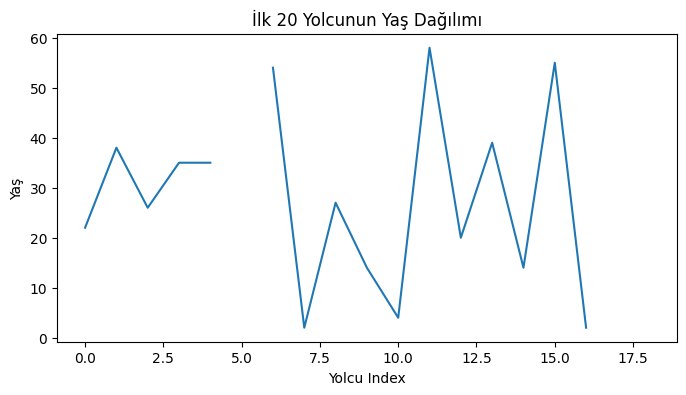

In [74]:
df["Age"].head(20).plot(
    figsize=(8,4),
    title="İlk 20 Yolcunun Yaş Dağılımı"
)

plt.xlabel("Yolcu Index")
plt.ylabel("Yaş")
plt.show()

### Scatter Plot

İki sayısal değişken arasındaki ilişkiyi gösterir.

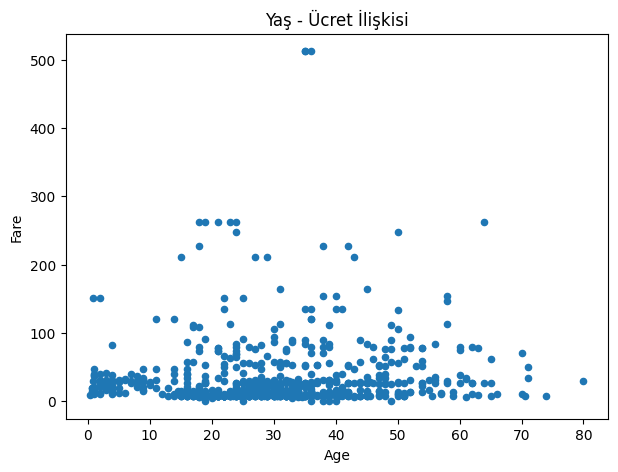

In [75]:
df.plot.scatter(
    x="Age",
    y="Fare",
    figsize=(7,5),
    title="Yaş - Ücret İlişkisi"
)

plt.show()

### Histogram

Veri dağılımını gösterir.

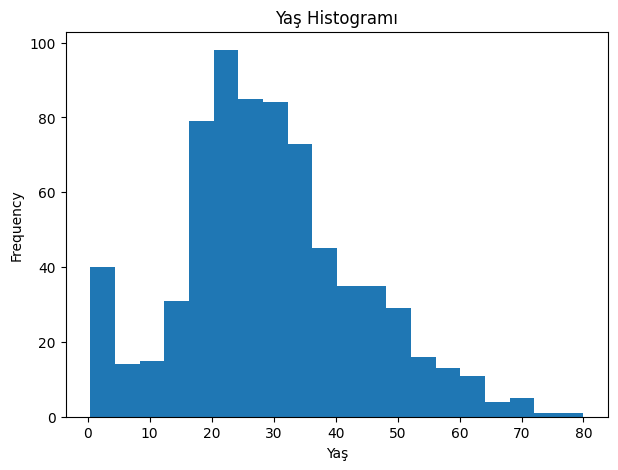

In [76]:
df["Age"].plot.hist(
    bins=20,
    figsize=(7,5),
    title="Yaş Histogramı"
)

plt.xlabel("Yaş")
plt.show()


### Pie Chart

Oransal dağılımları gösterir.

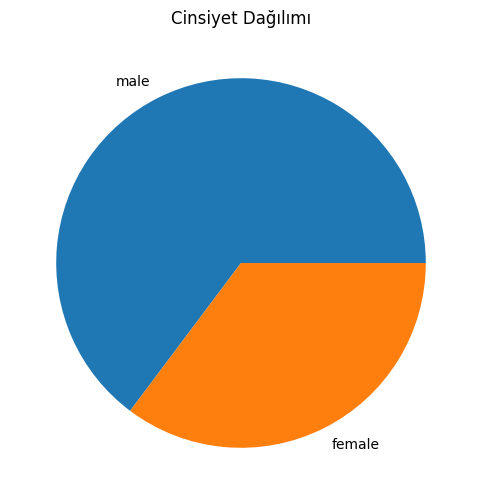

In [78]:
df["Sex"].value_counts().plot.pie(
    figsize=(6,6),
    title="Cinsiyet Dağılımı"
)

plt.ylabel("")
plt.show()

### Bar Plot

Kategorik karşılaştırmalarda kullanılır.

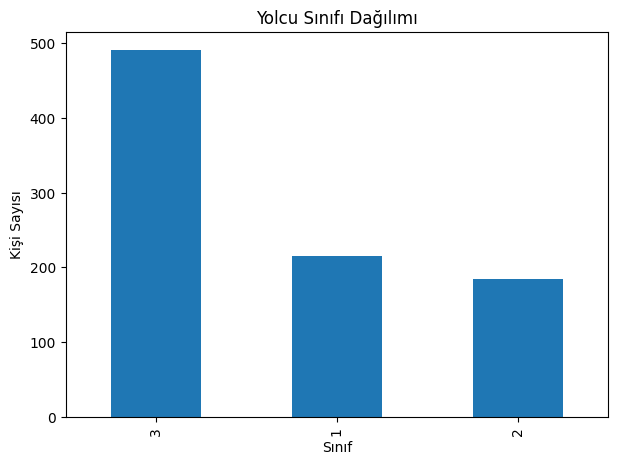

In [79]:
df["Pclass"].value_counts().plot.bar(
    figsize=(7,5),
    title="Yolcu Sınıfı Dağılımı"
)

plt.xlabel("Sınıf")
plt.ylabel("Kişi Sayısı")
plt.show()

### Box Plot

Aykırı değerleri görmek için çok kullanılır.

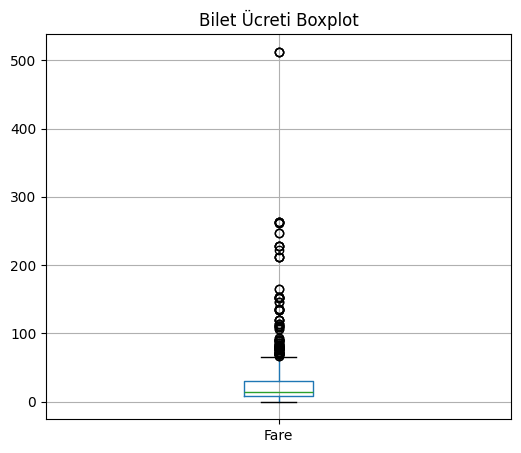

In [82]:
df.boxplot(
    column="Fare",
    figsize=(6,5)
)

plt.title("Bilet Ücreti Boxplot")
plt.show()

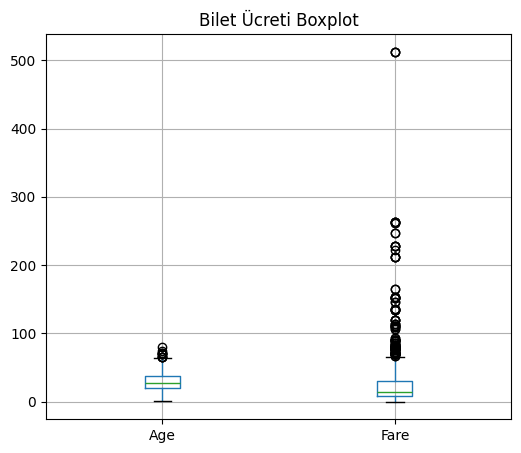

In [83]:
df.boxplot(
    column=["Age","Fare"],
    figsize=(6,5)
)

plt.title("Bilet Ücreti Boxplot")
plt.show()

### Area Plot

Kümülatif değişimlerde kullanılır.

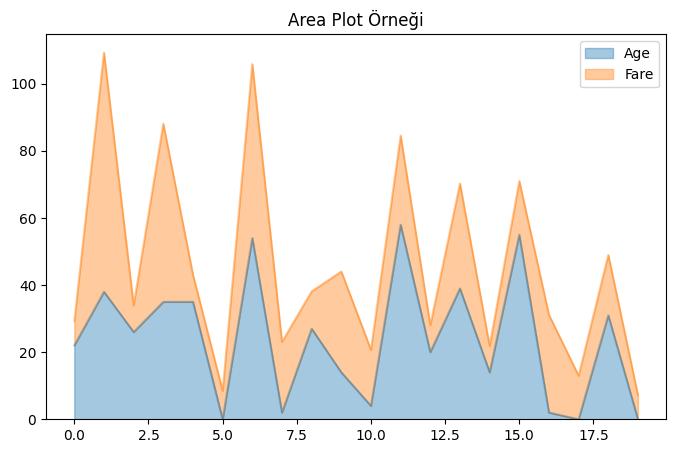

In [84]:
area_df = df[["Age", "Fare"]].head(20)

area_df.plot.area(
    alpha=0.4,
    figsize=(8,5),
    title="Area Plot Örneği"
)

plt.show()

### Hexbin Plot

Büyük veri setlerinde scatter yerine kullanılır.

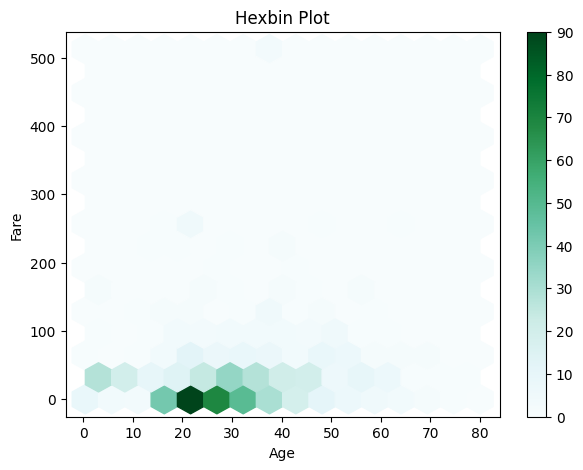

In [90]:
df.plot.hexbin(
    x="Age",
    y="Fare",
    gridsize=15,
    figsize=(7,5),
    title="Hexbin Plot"
)

plt.show()

### Subplot

Çoklu Grafik, her sütunu ayrı grafikte gösterir.

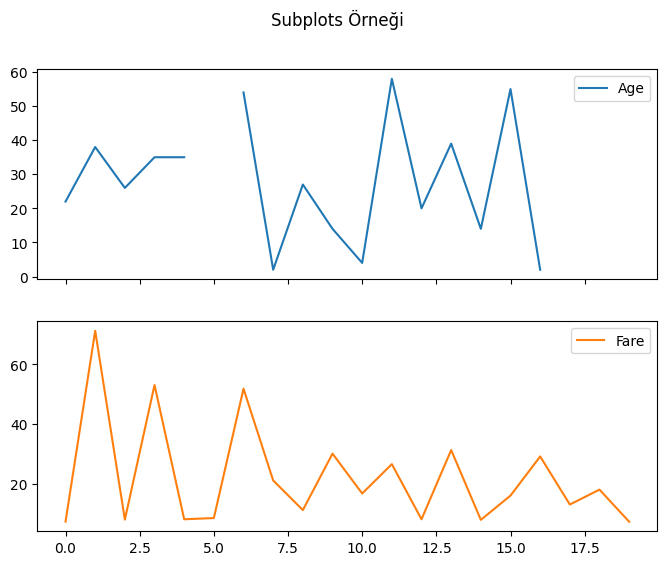

In [86]:
df[["Age", "Fare"]].head(20).plot(
    subplots=True,
    figsize=(8,6),
    title="Subplots Örneği"
)

plt.show()

### Stacked Plot

Kategorik verileri üst üste gösterir.

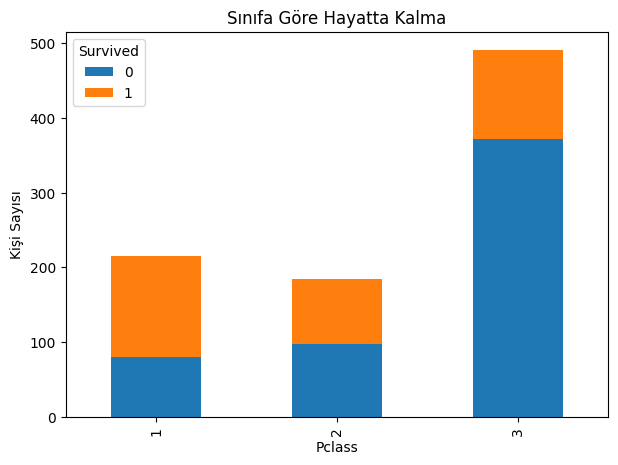

In [88]:
stacked_data = pd.crosstab(
    df["Pclass"],
    df["Survived"]
)

stacked_data.plot.bar(
    stacked=True,
    figsize=(7,5),
    title="Sınıfa Göre Hayatta Kalma"
)

plt.xlabel("Pclass")
plt.ylabel("Kişi Sayısı")
plt.show()
